##Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objectives

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

- Facilitate the process of visa approvals.
- Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.






## DataSet Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

- case_id: ID of each visa application
- continent: Information of continent the employee
- education_of_employee: Information of education of the employee
- has_job_experience: Does the employee has any job experience? Y= Yes; N = No
- requires_job_training: Does the employee require any job training? Y = Yes; N = No
- no_of_employees: Number of employees in the employer's company
- yr_of_estab: Year in which the employer's company was established
- region_of_employment: Information of foreign worker's intended region of employment in the US.
- prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
- unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
- case_status: Flag indicating if the Visa was certified or denied

## Importing libraries

In [ ]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To supress warnings
import warnings
# To save model
import joblib

warnings.filterwarnings("ignore")



## Loading Data

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the dataset
data_org = pd.read_csv("/content/drive/MyDrive/content/drive/EasyVisa.csv")

## Data Overview

In [ ]:
# Checking the number of rows and columns in the data
data_org.shape

(25480, 12)

In [ ]:
# Copy the data to another dataframe
data = data_org.copy()

In [ ]:
# view the first 5 rows of the data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
# view the last 5 rows of the data
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [ ]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- There are a total of 11 columns and 25480 observations in the dataset
- There is no null values
- There are 3 categorical and 8 numerical features

In [ ]:


# Drop case_id column as it has no significance
data.drop('case_id',axis=1,inplace=True)

### Check Sample

In [ ]:
data.sample()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
5722,South America,Bachelor's,Y,N,2968,1921,West,90911.470,Month,Y,Certified


In [ ]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

- no duplicates in the data

In [ ]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
continent,0.000
education_of_employee,0.000
has_job_experience,0.000
requires_job_training,0.000
no_of_employees,0.000
yr_of_estab,0.000
region_of_employment,0.000
prevailing_wage,0.000
unit_of_wage,0.000
full_time_position,0.000


- There are no missing values in the `DataSet`

**Let's check the number of unique values in each column**

In [ ]:
data.nunique()

,0
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4
full_time_position,2


- There are data from 6 continents
- We have only three numerical features no_of_employees,yr_of_estab and prevailing_wage, the rest are categorical


In [ ]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


- There are -ve values in the no of employees column, which is incorrect data
- The minimum of prevailing wage is also seems very less

### Checking the value count for each category of categorical variables

In [ ]:

# Printing number of count of each unique value in each column
for column in data.columns:
    print(data[column].value_counts())
    print("-" * 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
----------------------------------------
no_of_employees
183      18
854      16
724      16
1476     15
766      15
         ..
3711      1
16399     1
4600      1
33210     1
4830      1
Name: count, Length: 7105, dtype: int64
----------------------------------------
yr_of_estab
1998    1134
2005    1051
2001    1017
2007     994
1999     870
        ... 
1820       6
1846       4
1822       4
1810       3
1824       2
Name: cou

- The total number of visa approved is 17018 and denied is 8462
- Most of the applications are from Asia
- North East Region got the highest number of applications
- 14802 applications have experience
- Majority of the applicants have Bachelors
- case_status has only two values, 'Denied' and 'Certified'

# EDA

## Univariate analysis

### Handling negative values in no_of_employees column

In [ ]:
print("No. of -ve values",data[data['no_of_employees']<0]['no_of_employees'].count())

No. of -ve values 33


In [ ]:
# convert -ve values to +ve
data['no_of_employees']=data['no_of_employees'].apply(lambda x: abs(x) if x<0 else x )
print("No. of -ve values",data[data['no_of_employees']<0]['no_of_employees'].count())

No. of -ve values 0


#### Applications status with respect to case_status

In [ ]:
print(data_org['case_status'].value_counts())

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64


- There are 17018 applicants got approval and 8462 got denied

In [ ]:
# Function to plot histogram
def plot_hist(data,feature,i):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.histplot(data,x=feature)


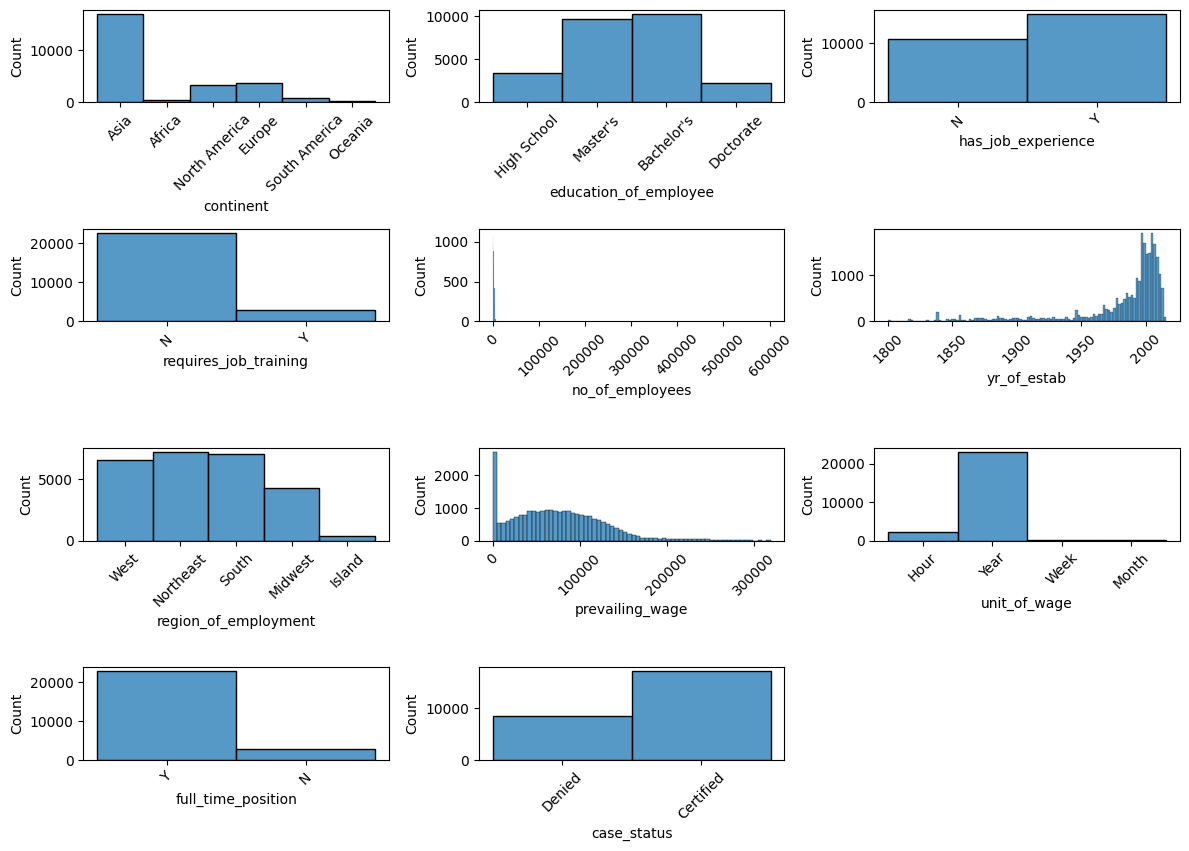

In [ ]:
# Iterate over each numerical features
plt.figure(figsize=(12,10))
for i,feature in enumerate(data.columns):
  plot_hist(data,feature,i)
plt.tight_layout()


- no.of employess  and prevailing_wage are right skewed
- Majority of the applications are for full time job
- year_of_estab is left skewed

In [ ]:
# Function to plot box plot
def plot_box(data,feature,i):
  # Define subplots
  plt.subplot(5,3,i+1)
  #plot boxplot
  sns.boxplot(data,x=feature,showmeans=True)


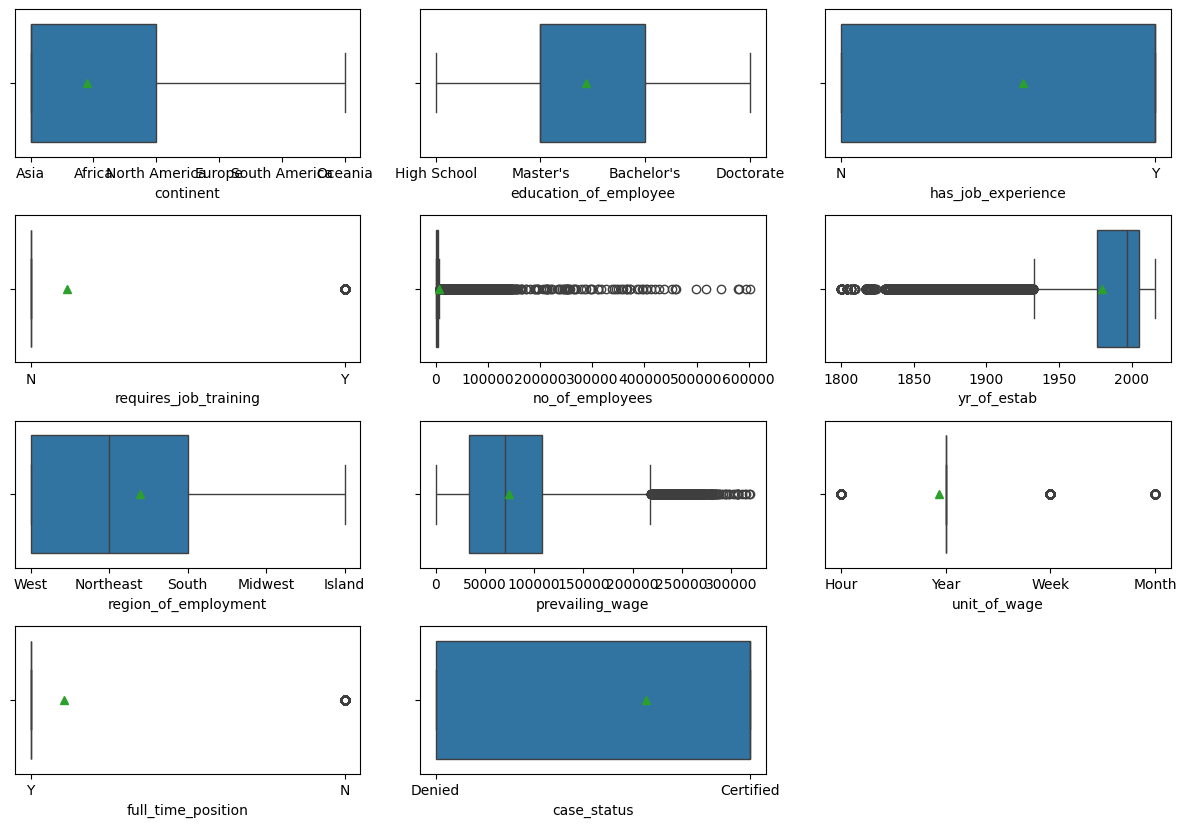

In [ ]:
# Set the figure size
plt.figure(figsize=(12,10))
# Iterate over each numerical features
for i,feature in enumerate(data.columns):
  plot_box(data,feature,i,)
plt.tight_layout()


- no.of employess,year_of_estab and prevailing_wage have outliers



## Feature Engineering

### New categorical column Visa_Approved




In [ ]:
# Create a new categorical column HasLoan
data['Visa_Approved'] = data['case_status'].apply(
    lambda x: 'No' if (x == 'Denied') else 'Yes')




In [ ]:
# Remove case_status
data.drop('case_status',axis=1,inplace=True)

In [ ]:
data.sample()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,Visa_Approved
14554,Asia,Bachelor's,Y,N,3230,1845,Midwest,137798.770,Year,Y,No


In [ ]:

# Select Categorical  and numerical columns
cat_cols=data.select_dtypes(include='object').columns.to_list()
num_cols=data.select_dtypes(exclude='object').columns.to_list()


### Define Plot functions

In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, ax,perc=False):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    i : index of feature
    perc: whether to display percentages instead of count (default is False)

    """
    total=data.shape[0]
    # # Define subplts
    # plt.subplot(3,len(cat_cols),i+1)
    # Adjust x labels to 45 degree
    plt.xticks(rotation=45, fontsize=15)
    # Plot countplot
    sns.countplot(
        data=data,
        x=feature,
        palette="Paired",ax=ax
    )
    # rotate x label by 45 degree
    ax.tick_params(axis='x', labelrotation=45)
    # display % over the bars
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage



In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
### function to plot distributions wrt target

def dist_plot_wrt_target(data, predictor, target):
    """
    Distribution plot
    data: dataframe
    predictor :independent feature
    target: target column

    """
    # Set Figsize and subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()
    total=data[data[target]==1].count()[0]
    # Plot for where target is zero
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="green",
        stat="density",
    )

   # Plot for where target is one
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    # Boxplot for where target
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
    # Boxplot without outliers
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# Function to create stacked  bar plot
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    # Number of unique predictor
    count = data[predictor].nunique()
    # Sort by the last class in target
    sorter = data[target].value_counts().index[-1]
    # Cross-tab: counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
   # Cross-tab: row-wise % (for stacked bar)
    tab = pd.crosstab(data[predictor], data[target], normalize='index').sort_values(by=sorter, ascending=False)

    # Plot
    ax = tab.plot(kind='bar', stacked=True, figsize=(count + 5, 6))
    # Format legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title=target)
    plt.ylabel('Percentage (%)')
    plt.xlabel(predictor)
    plt.xticks(rotation=45)

    # Add percentage labels in each segment
    for container in ax.containers:
        ax.bar_label(container,label_type='center',fmt='%.2f%%',               # Format as percentage
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

### Observation on No of Employees

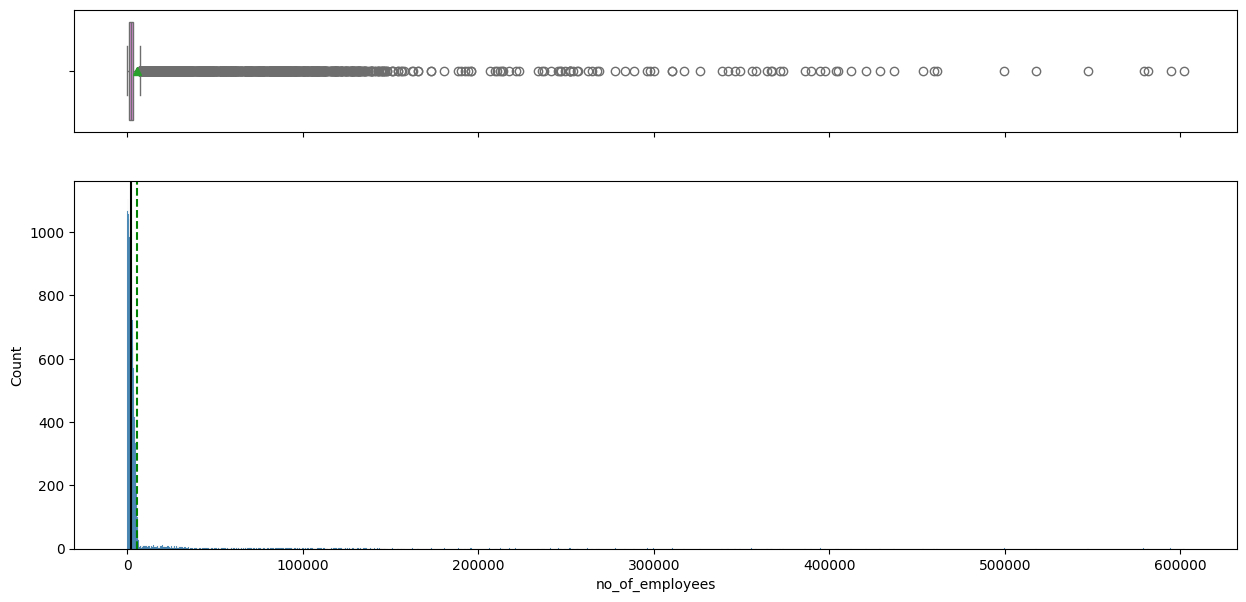

In [ ]:
# Observations on Customer_age
histogram_boxplot(data, "no_of_employees")

- The distribution of no.of employess is right-skewed
- The boxplot shows that a lot of outliers outliers at the right end
- We will not treat these outliers as they represent real values

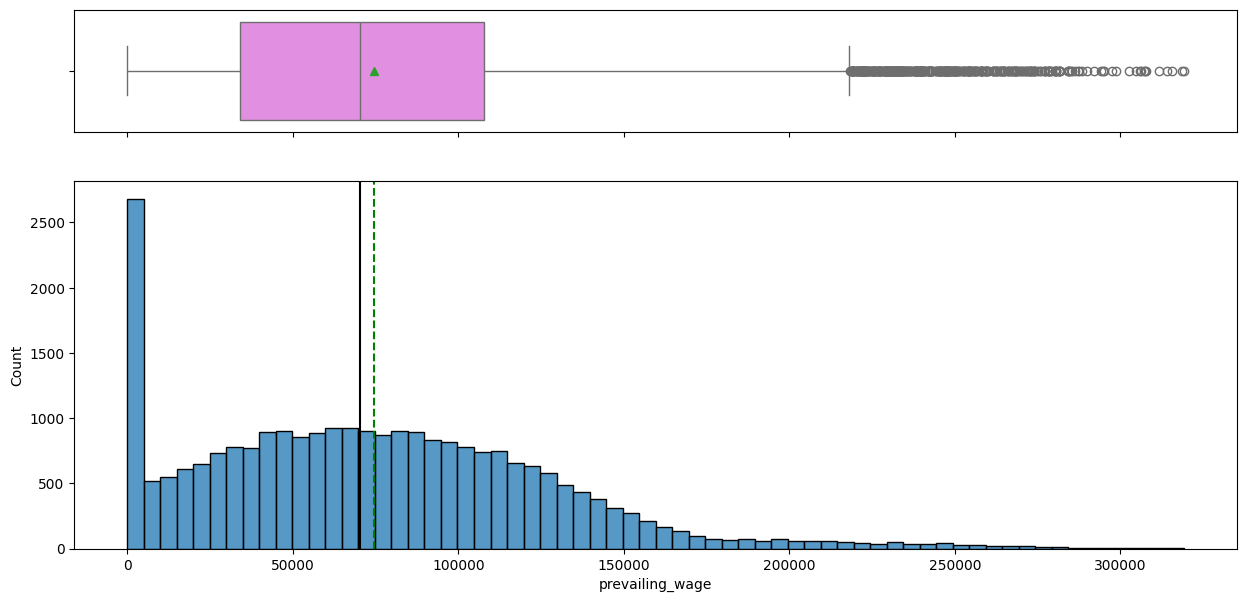

In [ ]:
# Observations on prevailing_wage
histogram_boxplot(data, "prevailing_wage")

- prevailing_wage is right skewed and has outliers


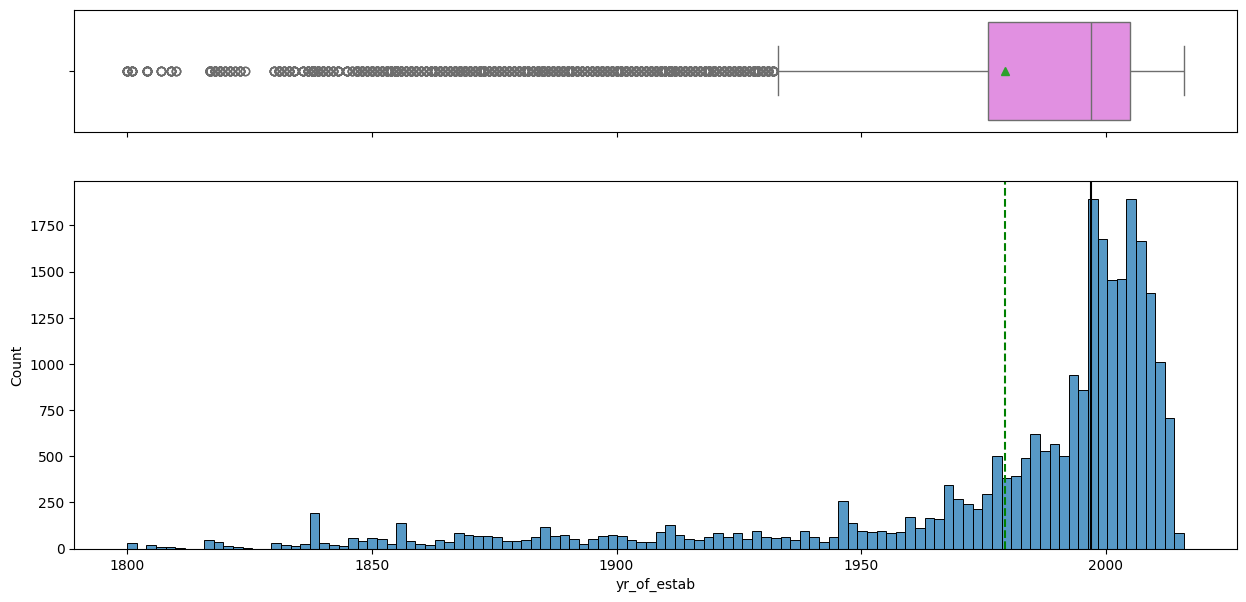

In [ ]:
#Observations on yr_of_estab
histogram_boxplot(data, "yr_of_estab")


- year of established is left skewed and has outliers

In [ ]:
# Function to plot countplot on categorical column
def plot_count(data,feature,ax):
  labeled_barplot(data, feature,ax,perc=True)



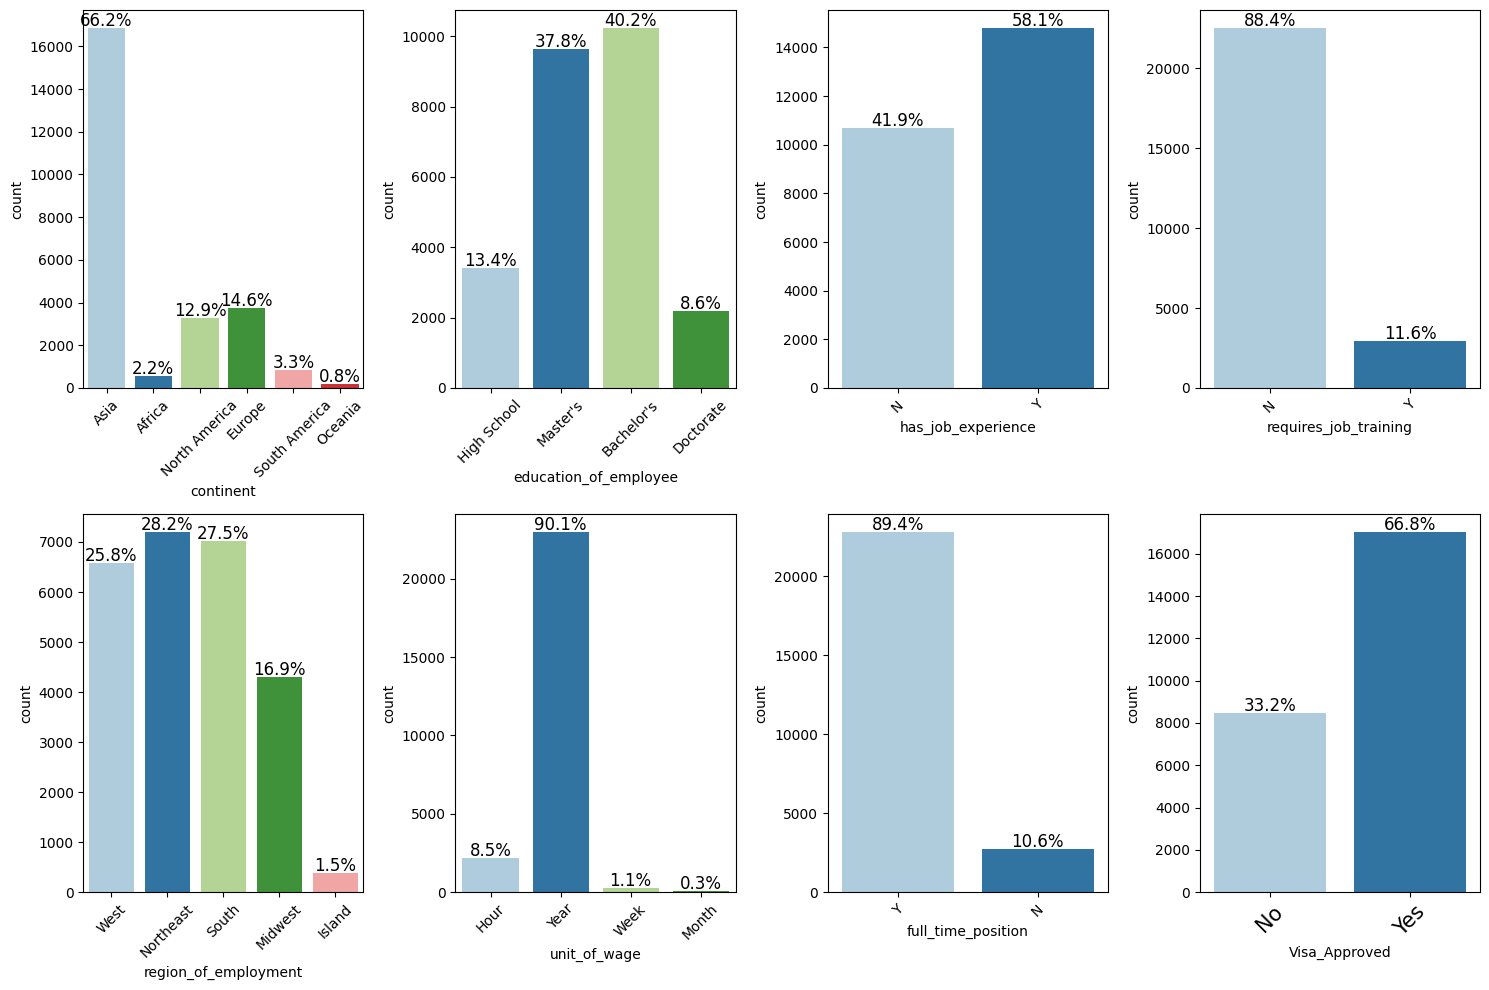

In [ ]:

# Determine layout
n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
# define axes and figure size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten for easy indexing
#Iterate over each categorical features
for i,feature in enumerate(cat_cols):
    plot_count(data,feature,ax=axes[i])
plt.tight_layout()




- ~ 67% of applications has been approved
- ~ 33% of applications has been not approved
- island region has less number of applications
- ~ 90% of applications has year as unit_of_wage
- ~ 9% of applications are PhD holders
- ~ 58% of applicants are experienced
- ~ 66% of applicants are from Asia
- ~ Oceania has least number of applications
- ~ 11% of applications are for part-time jobs

### Bivariate analysis
#### Find Correlation

<Axes: >

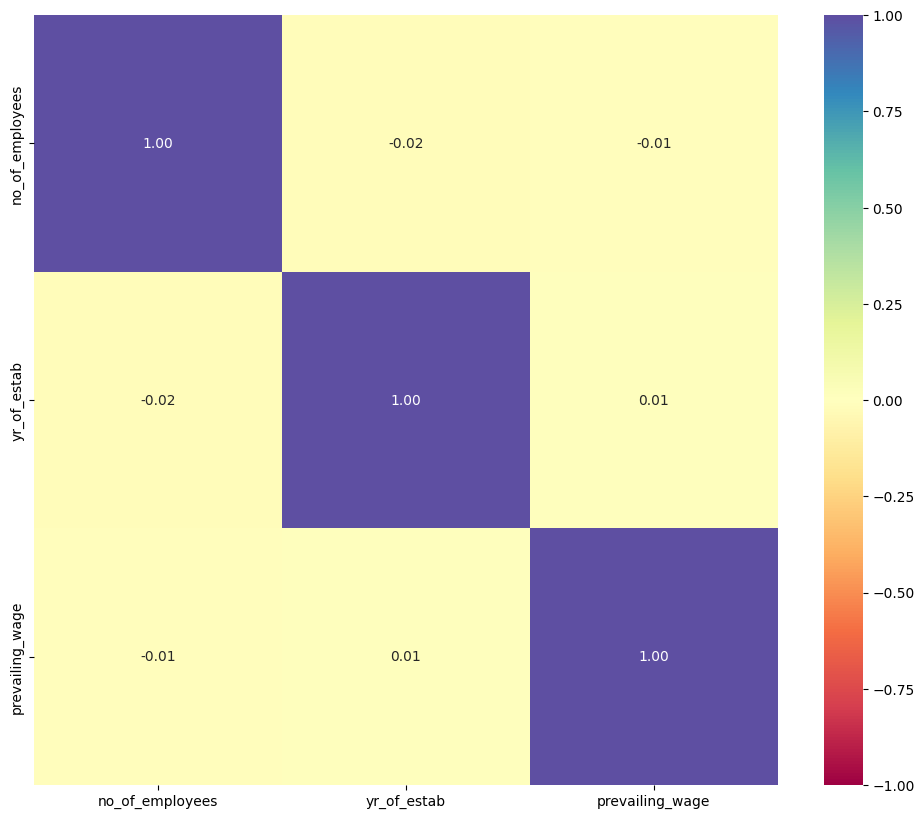

In [ ]:
# Define the size of the plot
plt.figure(figsize=(12,10))
# plotting the heatmap for correlation
sns.heatmap(data.corr(numeric_only=True),annot=True,vmin=-1,vmax=1,fmt="0.2f",cmap="Spectral")

- There is no significant correlation found between numerical features

### Visualize the relationships

[]

<Figure size 1500x1500 with 0 Axes>

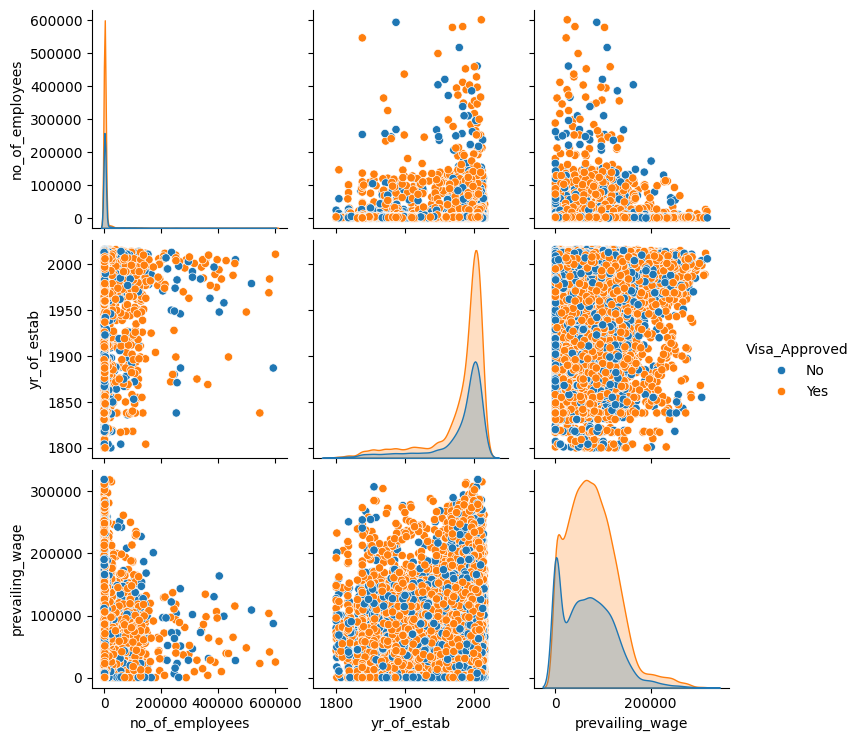

In [ ]:
# Plotting a pairplot
#Set the figure size
plt.figure(figsize=(15,15))
# Plot pairwise graphs
sns.pairplot(data,hue='Visa_Approved')
plt.plot()

- The pairplot also proves no correlation between numerical features

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

Visa_Approved            No    Yes    All
education_of_employee                    
All                    8462  17018  25480
Bachelor's             3867   6367  10234
High School            2256   1164   3420
Master's               2059   7575   9634
Doctorate               280   1912   2192
------------------------------------------------------------------------------------------------------------------------


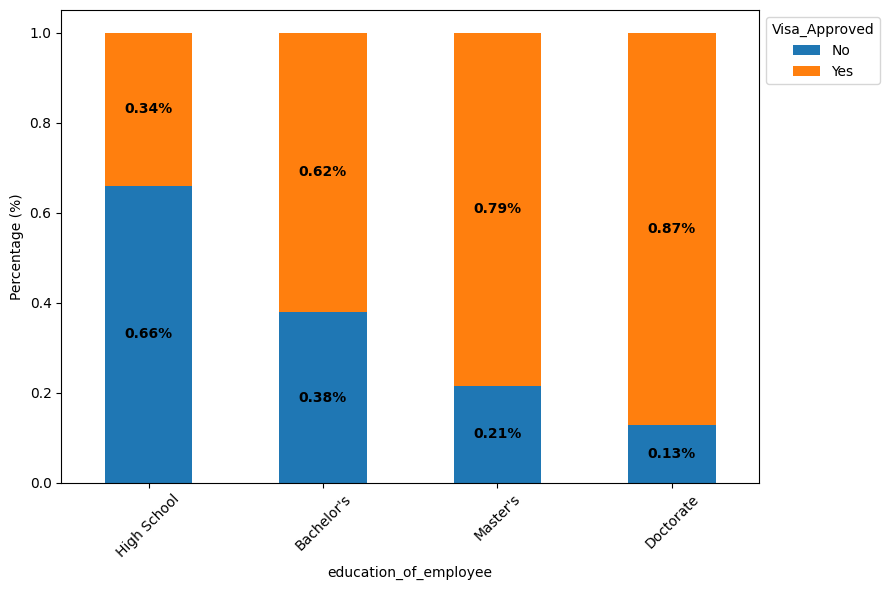

In [ ]:
# Stacked bar plot on Education of Employee
stacked_barplot(data, "education_of_employee", "Visa_Approved")

- ~ 34% only highschool qualified aplicants got approval
- ~ 87% of doctorate holding applicants got approval

Visa_Approved    No    Yes    All
continent                        
All            8462  17018  25480
Asia           5849  11012  16861
North America  1255   2037   3292
Europe          775   2957   3732
South America   359    493    852
Africa          154    397    551
Oceania          70    122    192
------------------------------------------------------------------------------------------------------------------------


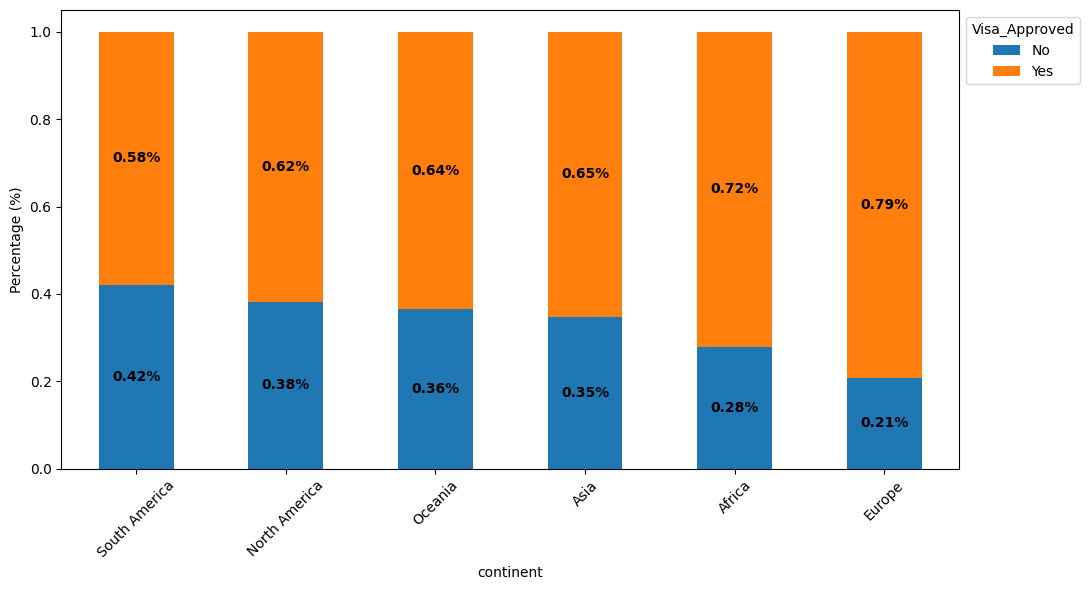

In [ ]:
# Stacked bar plot on Continent
stacked_barplot(data, "continent", "Visa_Approved")

- ~ 79% of applicants from Europe got approved
- Majority of applications from Europe and Africa has been approved
- Only ~ 42% of applications from South America has not been approved, the highest case compared to other continents

Visa_Approved         No    Yes    All
has_job_experience                    
All                 8462  17018  25480
N                   4684   5994  10678
Y                   3778  11024  14802
------------------------------------------------------------------------------------------------------------------------


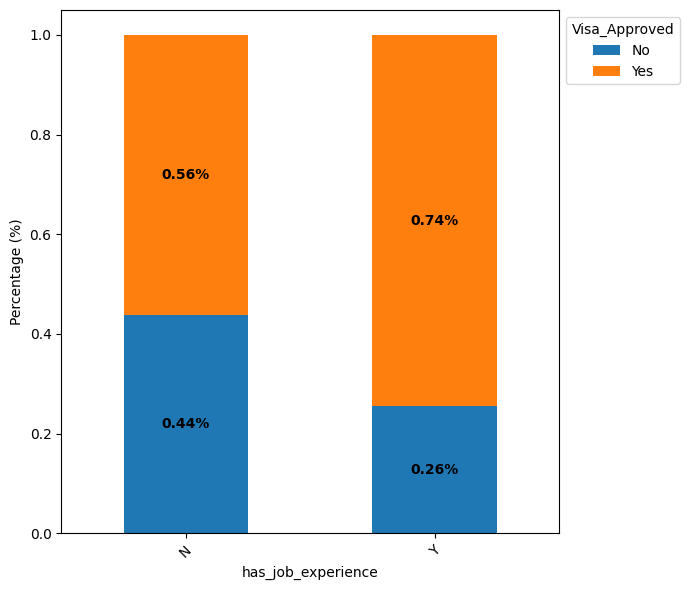

In [ ]:
# Stacked bar plot on Job Expereince
stacked_barplot(data, "has_job_experience", "Visa_Approved")

- NonExperenced applicants (~ 56% ) got approval compared to experienced persons

Visa_Approved            No    Yes    All
requires_job_training                    
All                    8462  17018  25480
N                      7513  15012  22525
Y                       949   2006   2955
------------------------------------------------------------------------------------------------------------------------


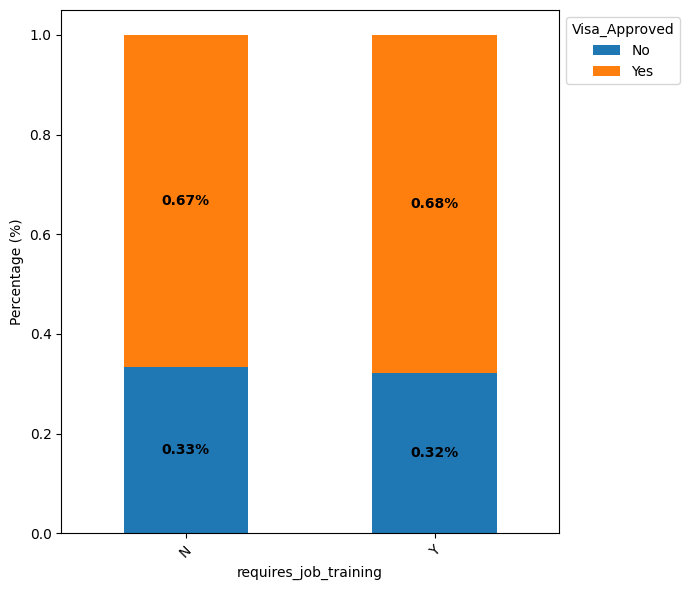

In [ ]:
# Stacked bar plot on requires_job_training
stacked_barplot(data, "requires_job_training", "Visa_Approved")

- There is no significance whether requires job training or not in approving visa

Visa_Approved           No    Yes    All
region_of_employment                    
All                   8462  17018  25480
Northeast             2669   4526   7195
West                  2486   4100   6586
South                 2104   4913   7017
Midwest               1054   3253   4307
Island                 149    226    375
------------------------------------------------------------------------------------------------------------------------


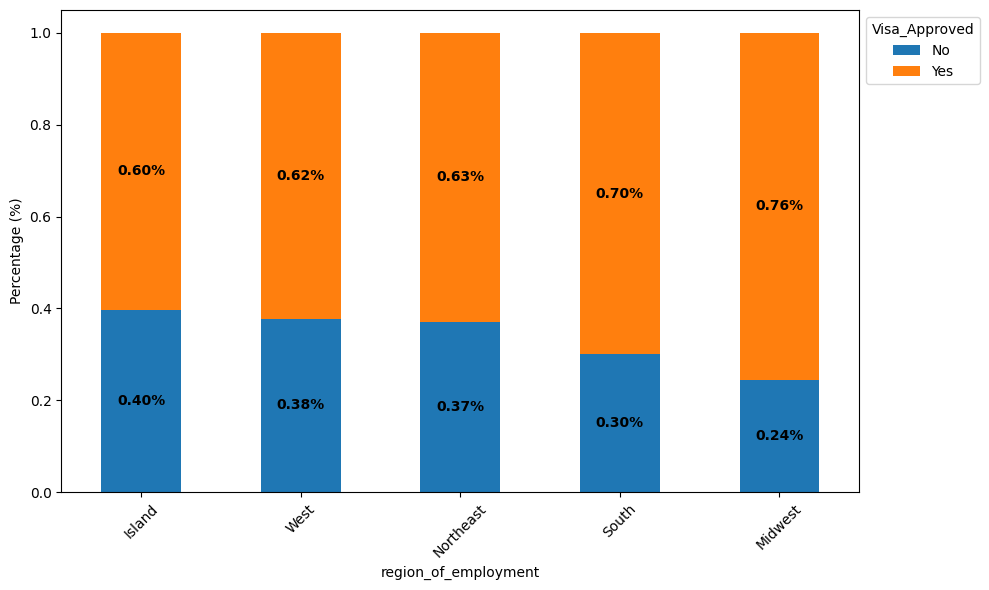

In [ ]:
# Stacked bar plot on region_of_employment
stacked_barplot(data, "region_of_employment", "Visa_Approved")

- ~ 76% of applications in the region Midwest got approval
- ~ 60% of applications in the region island got approval

Visa_Approved    No    Yes    All
unit_of_wage                     
All            8462  17018  25480
Year           6915  16047  22962
Hour           1410    747   2157
Week            103    169    272
Month            34     55     89
------------------------------------------------------------------------------------------------------------------------


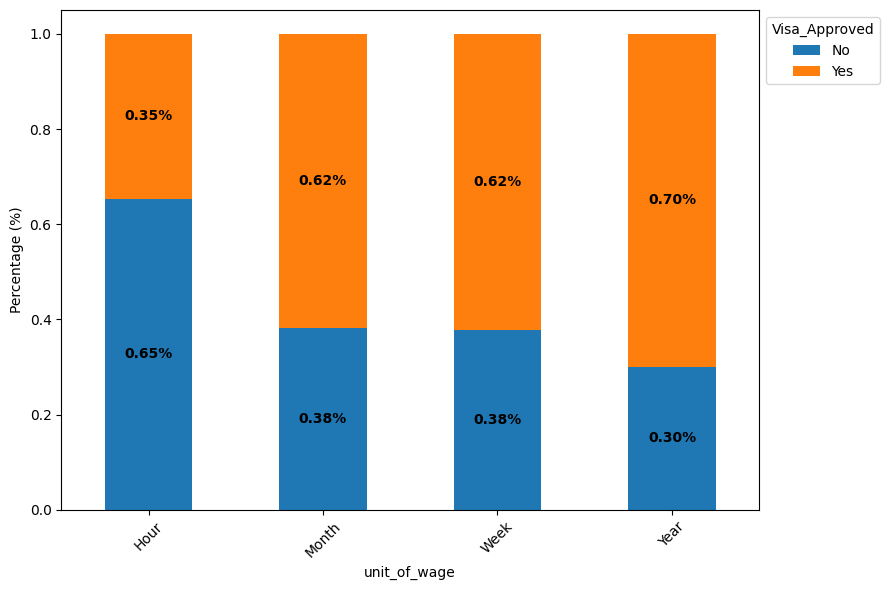

In [ ]:
# Stacked bar plot on unit_of_wage
stacked_barplot(data, "unit_of_wage", "Visa_Approved")

- ~ 70% of applications in unit of wage as Year got approval
- Majority of applications  from Hourly wage got rejected.

Visa_Approved         No    Yes    All
full_time_position                    
All                 8462  17018  25480
Y                   7610  15163  22773
N                    852   1855   2707
------------------------------------------------------------------------------------------------------------------------


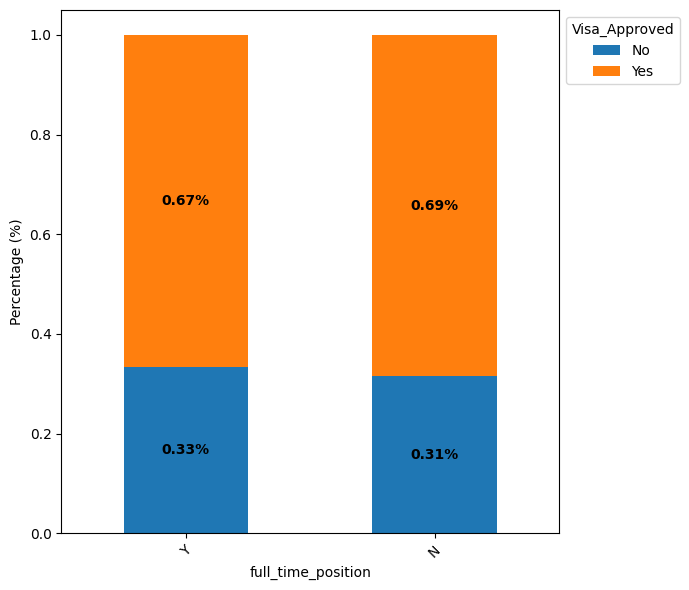

In [ ]:
# Stacked bar plot on Full time position
stacked_barplot(data, "full_time_position", "Visa_Approved")

- There is no significance whether job is full time position  or not in approving visa


## Data Preprocessing

In [ ]:
# Copying data to df
df = data.copy()

In [ ]:
# Replace values in Visa Approved to numerical for score calculations
X = df.drop(["Visa_Approved"], axis=1)
y = df["Visa_Approved"].replace({"Yes": 1, "No": 0})


In [ ]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


### Generate Dummy values for categorical columns



In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

# Model Building

### Model evaluation criterion

### We will be using Recall as a metric for our model performance because here OFLC could face 2 types of losses
1. Could give approval to unskilled/ not Qualified persons - Loss of Experts and Security issues.
2. Not give Approval to Skilled/Qualified persons - Loss of opportunity

### Which Loss is greater?
* Could give approval to Unskilled persons

### How to reduce this loss i.e need to reduce False Negatives?
* The OFLC wants recall to be maximized i.e. we need to reduce the number of false negatives.

### Initial Model Building on Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9888344760039177
Random forest: 1.0
GBM: 0.8789422135161606
Adaboost: 0.8882468168462292
dtree: 1.0

Validation Performance:

Bagging: 0.7831962397179788
Random forest: 0.8422444183313749
GBM: 0.8733842538190364
Adaboost: 0.8807285546415982
dtree: 0.7479435957696827


In [ ]:
print("\nTraining and Validation Performance Difference on Original Data:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference on Original Data:

Bagging: Training Score: 0.9888, Validation Score: 0.7832, Difference: 0.2056
Random forest: Training Score: 1.0000, Validation Score: 0.8422, Difference: 0.1578
GBM: Training Score: 0.8789, Validation Score: 0.8734, Difference: 0.0056
Adaboost: Training Score: 0.8882, Validation Score: 0.8807, Difference: 0.0075
dtree: Training Score: 1.0000, Validation Score: 0.7479, Difference: 0.2521


- AdaBoost shows the best performance followed by GBM due to:

**Highest validation score** (0.8807) and
**Minimal overfitting** (difference = 0.0075)

## Model Building Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.98256611165524
Random forest: 0.9999020568070519
GBM: 0.8535749265426053
Adaboost: 0.8841332027424094
dtree: 1.0

Validation Performance:

Bagging: 0.7532314923619271
Random forest: 0.8125734430082256
GBM: 0.8463572267920094
Adaboost: 0.882491186839013
dtree: 0.7153349001175088


In [ ]:
print("\nTraining and Validation Performance Difference on OverSampled Data:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference on OverSampled Data:

Bagging: Training Score: 0.9826, Validation Score: 0.7532, Difference: 0.2293
Random forest: Training Score: 0.9999, Validation Score: 0.8126, Difference: 0.1873
GBM: Training Score: 0.8536, Validation Score: 0.8464, Difference: 0.0072
Adaboost: Training Score: 0.8841, Validation Score: 0.8825, Difference: 0.0016
dtree: Training Score: 1.0000, Validation Score: 0.7153, Difference: 0.2847


- AdaBoost is again the best performer on validation, followed by GBM and RandomForest.


## Model Building- Under Sampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9686884600236314
Random forest: 1.0
GBM: 0.7479322567940134
Adaboost: 0.715833005120126
dtree: 1.0

Validation Performance:

Bagging: 0.6178025851938895
Random forest: 0.6745005875440658
GBM: 0.7291421856639247
Adaboost: 0.7159224441833137
dtree: 0.631316098707403


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9687, Validation Score: 0.6178, Difference: 0.3509
Random forest: Training Score: 1.0000, Validation Score: 0.6745, Difference: 0.3255
GBM: Training Score: 0.7479, Validation Score: 0.7291, Difference: 0.0188
Adaboost: Training Score: 0.7158, Validation Score: 0.7159, Difference: -0.0001
dtree: Training Score: 1.0000, Validation Score: 0.6313, Difference: 0.3687


-AdaBoost is the best performer because of the fact it has the Best validation score: 0.7159 and almost no overfitting (difference = –0.0001).

## Model Building and Comparison on Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.70812928501469
Random forest: 84.31929480901077
GBM: 87.2771792360431
Adaboost: 88.86385896180215
Xgboost: 85.41625857002938
dtree: 73.64348677766894

Validation Performance:

Bagging: 0.7711515863689776
Random forest: 0.8284371327849589
GBM: 0.8733842538190364
Adaboost: 0.8807285546415982
Xgboost: 0.8519388954171563
dtree: 0.7405992949471211


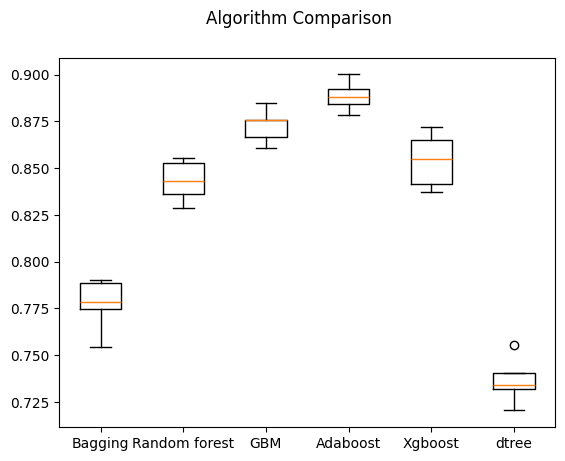

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

- We can see that the Adaboost  is giving the highest cross-validated recall followed by GBM,XGBoost and RandomForest on Original data
- The boxplot shows that the performance of Adaboost and GBM is consistent and their performance on the validation set is also good \
**The best three models based on overall performance across original, oversampled, and undersampled data are**

- AdaBoost is the most consistent top performer because of
highest validation scores in 2/3 datasets,minimal overfitting (difference = 0)
and robust generalization.
GBM is in second position, best in  undersampled data and less overfitting
Slightly lower validation than AdaBoost but highly reliable
Random Forest is in 3rd position and has good balance of accuracy and robustness.

- We will tune the best three models i.e. Adaboost, GBM and Random Forest on original data and see if the performance improves

## Hyperparameter Tuning

**We will tune Adaboost, GBM and RandomForest models using GridSearchCV and RandomizedSearchCV using original data since these models gave good validation scores in original data and have less difference in the recall scores of training and validation set. We will also compare the performance and time taken by these two methods - grid search and randomized search.**

**Define built in functions to calculate different metrics and confusion matrix.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## AdaBoost

### GridSearchCV

In [ ]:
# Creating pipeline
dtc=DecisionTreeClassifier()
#Initialize AdaBoost
model=AdaBoostClassifier(estimator=dtc, random_state=1) #taking default parameters with decision tree as base estimator

# set parameters
param_grid = {
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__max_depth': [3, 4, 5],
    'estimator__min_samples_split': [2, 7, 10]
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'estimator__criterion': 'entropy', 'estimator__max_depth': 4, 'estimator__min_samples_split': 7} 
Score: 0.8668952007835455


In [ ]:
# Creating new pipeline with best parameters
# base estimator with best parameters
dtc = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=7,
    random_state=1
)

# Pass the best parameter to AdaBoost
model_tuned1 = AdaBoostClassifier(
    estimator=dtc,
    random_state=1
)


# Fit the model on training data
model_tuned1.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=4,
                                                    min_samples_split=7,
                                                    random_state=1),
                   random_state=1)

In [ ]:
# Calculating different metrics on train set
adaboost_grid_train = model_performance_classification_sklearn(
    model_tuned1, X_train, y_train
)
print("Training performance:")
adaboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.751,0.876,0.779,0.824


In [ ]:
# Calculating different metrics on validation set
adaboost_grid_val = model_performance_classification_sklearn(model_tuned1, X_val, y_val)
print("Validation performance:")
adaboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.748,0.871,0.778,0.822


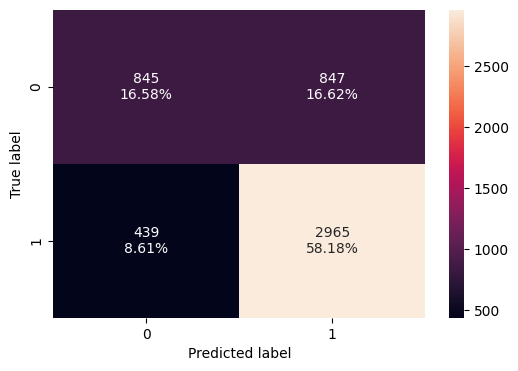

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(model_tuned1, X_val, y_val)

- The validation recall has same performance to the validation recall on model with default parameters
- The tuned adaboost model  generalize well on unseen data
- The validation recall is still just ~87% i.e. the model is good enough for processing visa

### RandomizedSearchCV

In [ ]:
# Creating pipeline
dtc=DecisionTreeClassifier()
# Create AdaBoost model using that base estimator
model=AdaBoostClassifier(estimator=dtc, random_state=1) #taking default parameters with decision tree as base estimator

# set parameters
param_grid = {
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__max_depth': [3, 4, 5],
    'estimator__min_samples_split': [2, 7, 10]
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'estimator__min_samples_split': 7, 'estimator__max_depth': 4, 'estimator__criterion': 'entropy'} with CV score=0.8668952007835455:


- The best parameter got from RandomizedSearch is same as that we got from GridSearch and cross validation score is also same. Hence we will use the parameters 'estimator__min_samples_split': 7, 'estimator__max_depth': 4, 'estimator__criterion': 'entropy'as the best parameter.

## GBM

### GridSearchCV

In [ ]:
%%time

#defining model
model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse','entropy'],
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1, verbose= 2)

#Fitting parameters in GridSeachCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters are {'criterion': 'squared_error', 'max_features': 1, 'n_estimators': 100, 'subsample': 1} with CV score=0.9223310479921645:
CPU times: user 6.32 s, sys: 1.15 s, total: 7.47 s
Wall time: 17min 23s


In [ ]:
# building model with best parameters
gb_tuned1 = GradientBoostingClassifier(
    random_state=1,
    n_estimators=100,
    subsample=1,
    criterion="squared_error",
    max_depth=1,
)

# Fit the model on training data
gb_tuned1.fit(X_train, y_train)
# Save the model
joblib.dump(gb_tuned1, '/content/drive/MyDrive//content/drive/gbtuned1.pkl')


['/content/drive/MyDrive//content/drive/gbtuned1.pkl']

In [ ]:
# Calculating different metrics on train set
gboost_grid_train = model_performance_classification_sklearn(
    gb_tuned1, X_train, y_train
)
print("Training performance:")
gboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.725,0.924,0.733,0.818


In [ ]:
# Calculating different metrics on validation set
gboost_grid_val = model_performance_classification_sklearn(gb_tuned1, X_val, y_val)
print("Validation performance:")
gboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.727,0.920,0.737,0.818


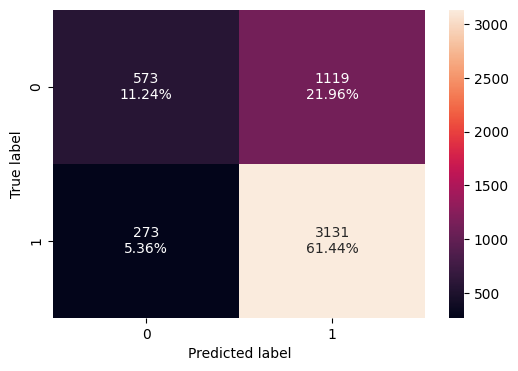

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(gb_tuned1, X_val, y_val)

- Recall has increased to ~92% as compared to the tuned Adaboost,
- The model is giving a generalized performance.
- The model can identify most of the rejecting applications

### RandomizedSearchCV

In [ ]:
%%time

#defining model
model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse','entropy'],
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
gb_tuned2 = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
gb_tuned2.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(gb_tuned2.best_params_,gb_tuned2.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 100, 'max_features': 1, 'criterion': 'friedman_mse'} with CV score=0.9041136141038197:
CPU times: user 2.62 s, sys: 427 ms, total: 3.04 s
Wall time: 5min 57s


In [ ]:
# building model with best parameters
gb_tuned2 = GradientBoostingClassifier(
    random_state=1,
    n_estimators=100,
    subsample=0.8,
    criterion="friedman_mse",
    max_features=1,
)

# Fit the model on training data
gb_tuned2.fit(X_train, y_train)
# Save the model
joblib.dump(gb_tuned2, '/content/drive/MyDrive//content/drive/gbtuned1.pkl')


['/content/drive/MyDrive//content/drive/gbtuned1.pkl']

In [ ]:
# Calculating different metrics on train set
gboost_random_train = model_performance_classification_sklearn(
    gb_tuned2, X_train, y_train
)
print("Training performance:")
gboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.742,0.916,0.752,0.826


In [ ]:
# Calculating different metrics on validation set
gboost_random_val = model_performance_classification_sklearn(gb_tuned2, X_val, y_val)
print("Validation performance:")
gboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.737,0.910,0.750,0.822


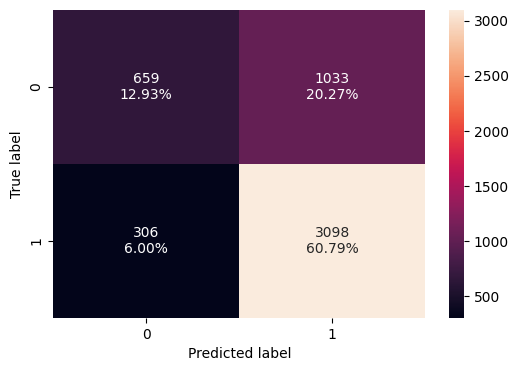

In [ ]:
~

- Recall has increased to ~91% as compared to the tuned Adaboost
- Model is performing poorly than GBoosting tuned with GridSearch

## Random Forest Classifier

Training performance:
    Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.712   0.835      0.758 0.795


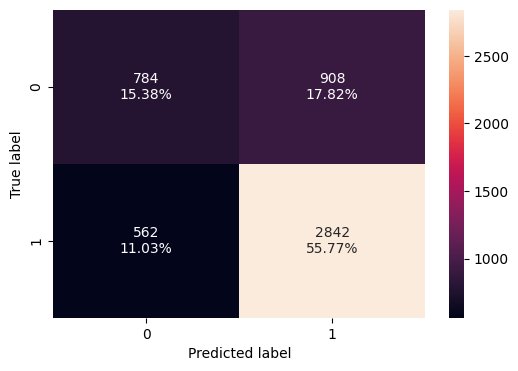

In [ ]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

- The model suffers from severe overfitting, it performs perfectly on training data but significantly worse on test data
- We will go for hyperparameter tuning

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(class_weight={0:0.18,1:0.82},random_state=1,oob_score=True,bootstrap=True)

parameters = {
                'max_depth': [3,4,7],
                'max_features': ['sqrt','log2'],
                'min_samples_leaf': [2,3],
                'min_samples_split': [2,7,10],
                'n_estimators':[100,150,200,250] }


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.18, 1: 0.82}, max_depth=7,
                       min_samples_leaf=3, min_samples_split=7, oob_score=True,
                       random_state=1)

Training performance:
    Accuracy  Recall  Precision    F1
0     0.673   1.000      0.671 0.803
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.671   0.999      0.670 0.802


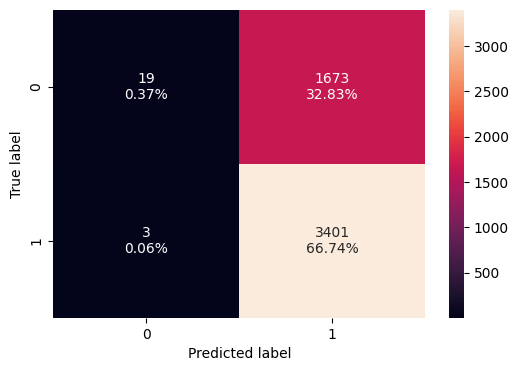

In [ ]:
#Calculating different metrics
rf_tuned_model_train=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train)
rf_tuned_model_val=model_performance_classification_sklearn(rf_tuned,X_val,y_val)
print("Testing performance:\n",rf_tuned_model_val)
#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned,X_val,y_val)

- Random Forest tuned with gridsearch has better recall value but precision is poor hence we give least preference to this model

### Comparing models from GridsearchCV and RandomisedsearchCV

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        adaboost_grid_train.T,
        gboost_grid_train.T,
        gboost_random_train.T,
        rf_tuned_model_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost with Grid search",
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "Random Forest with Grid Search"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost with Grid search,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,Random Forest with Grid Search
Accuracy,0.751,0.725,0.742,0.673
Recall,0.876,0.924,0.916,1.000
Precision,0.779,0.733,0.752,0.671
F1,0.824,0.818,0.826,0.803


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        adaboost_grid_val.T,
        gboost_grid_val.T,
        gboost_random_val.T,
        rf_tuned_model_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "AdaBoost with Grid search",
    "Gradient Boost Tuned with Grid search",
    "Gradient Boost Tuned with Random search",
    "Random Forest with Grid Search"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost with Grid search,Gradient Boost Tuned with Grid search,Gradient Boost Tuned with Random search,Random Forest with Grid Search
Accuracy,0.748,0.727,0.737,0.671
Recall,0.871,0.920,0.910,0.999
Precision,0.778,0.737,0.750,0.670
F1,0.822,0.818,0.822,0.802


- We can see that Gradient Boost is giving a similar performance with GridSearchCV and RandomizedSearchCV with a validation recall of ~92, but there is a huge difference between recall and precision score and model accuracy is slightly lesser than AdaBoost.
- Let's see the feature importance from the gradient boost model tuned with GridSearchCV.

In [ ]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(gb_tuned1, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.718,0.920,0.729,0.814


- The best model Gradient Boost generalizes well on unseen data, as the scores almost same in training and validation set
- Hence the best model for Visa Processing application is GradientBoost.

#### Feature Importance from Gradient Boost

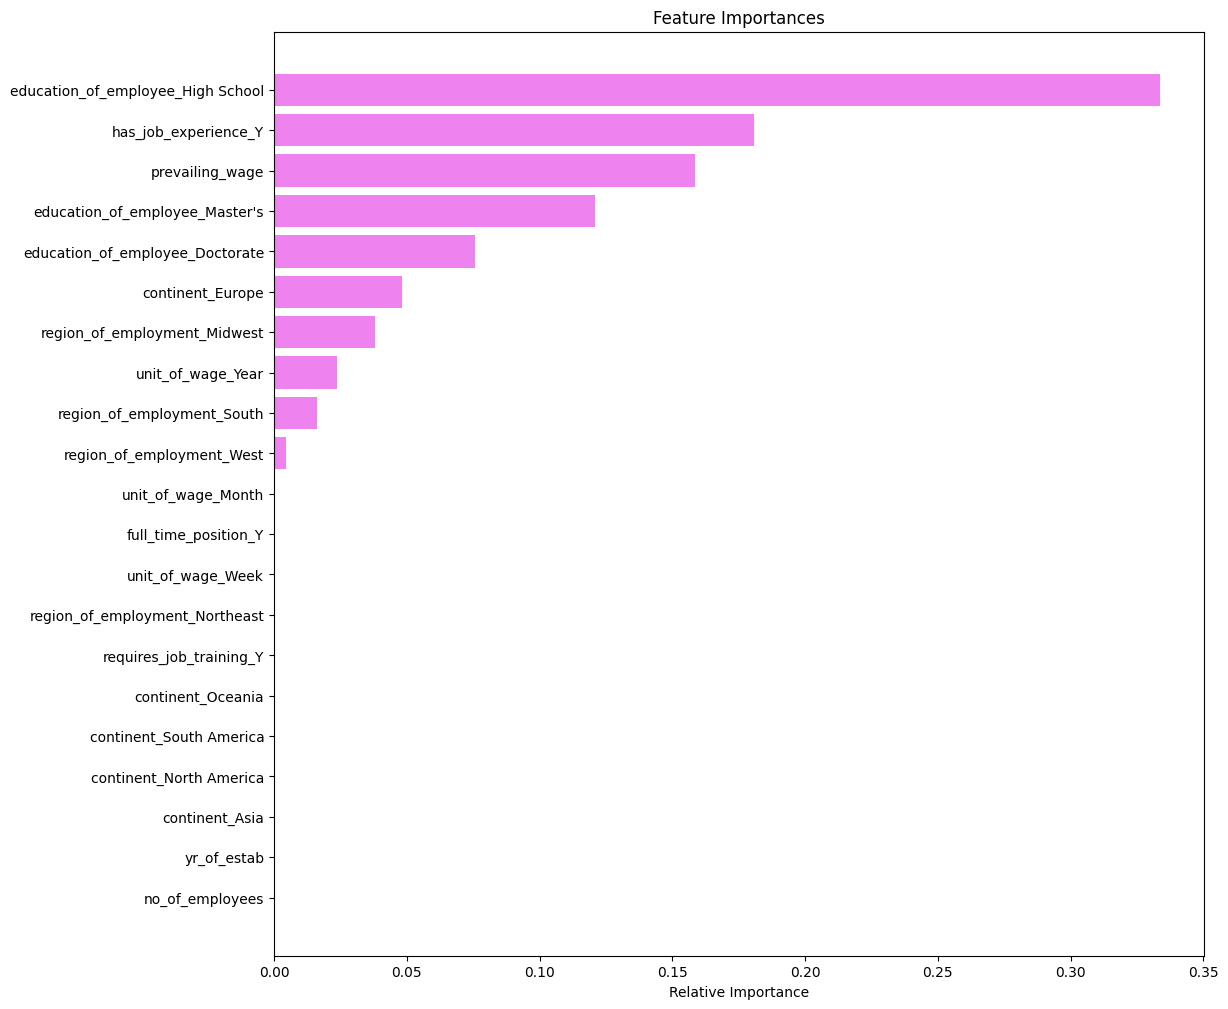

In [ ]:
feature_names = X_train.columns
importances = gb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Education of Employee_Highschool, Has_job_experience_Y and Prevaliling wage , these are the top three features that play an important role in Gradient Boosting.

#### Feature Importance from Adaboost

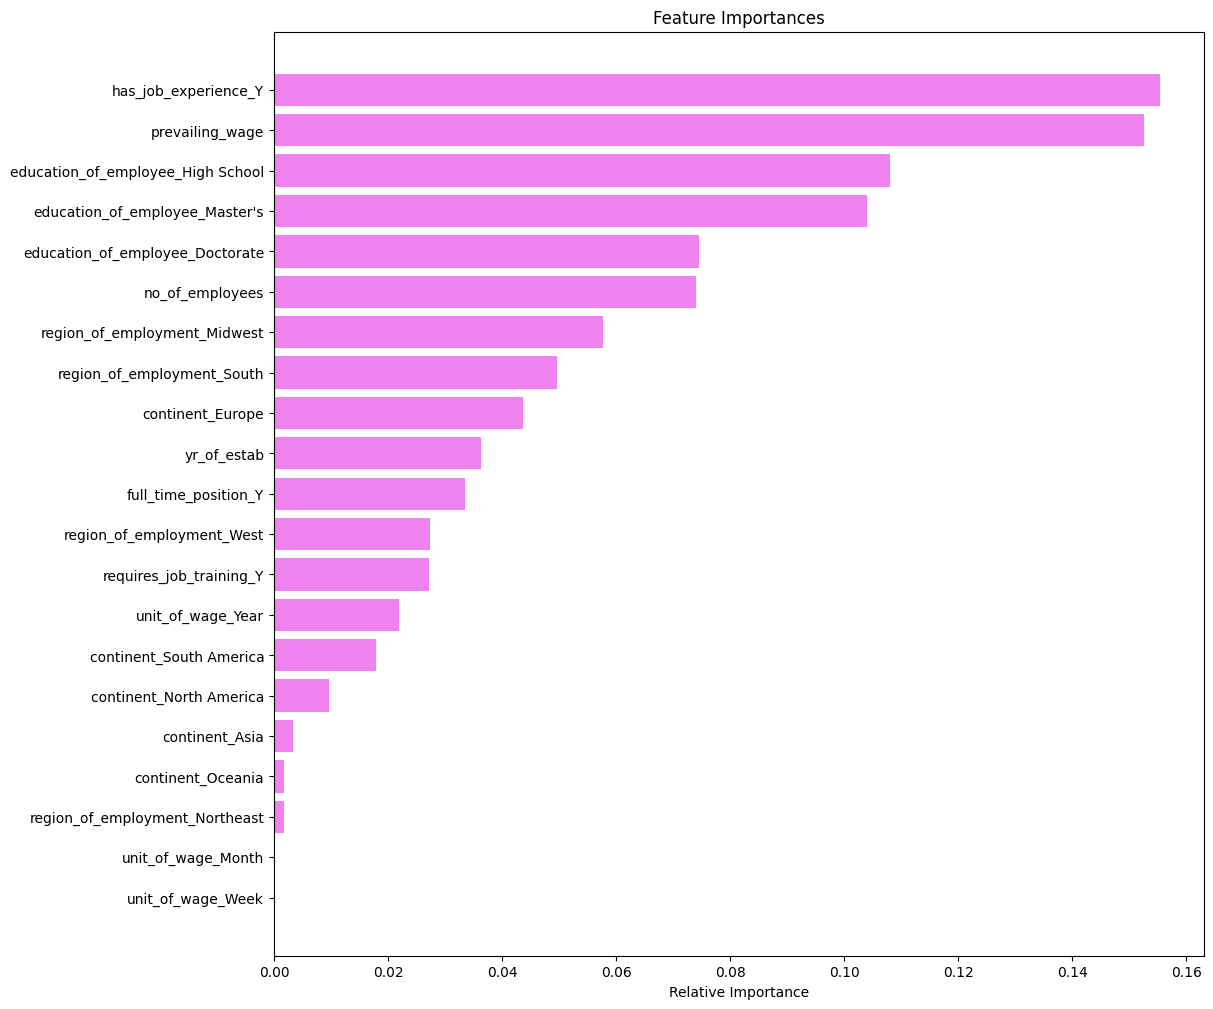

In [ ]:
feature_names = X_train.columns
importances = model_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

-  Has_job_experience_Y and Prevaliling wage and Education of Employee_Highschool, these are the top three features  which respectively play an important role in Adaboost.

# Conclusion and Insights

- Adapt the model GradientBoost tuned with Grid Search since this one has a good recall score compared to others. But the performance of the model can be improved especially in terms of precision and OFLC can use the model for new applications once desired level of model performance is achieved.
- The precision can still be improved to reduce false approvals
- It seems Education in High school is the most important feature to consider while approval, this is a contradictory feature, since most of the applications  holding only highschool has been rejected. This feature should be investicated further to see whether the applicants hold any other technical qualifications too.
- We saw that Education of applicants play major role in the decision, hence try to collect more information on this such as extra certificates, technical diplomas etc from the applicants.
- Applicants with experience are more likely to get approved.
- Midwest region has more openning than compared to other region and majority of applicants from Europe got approved.
- The applicants from other continents except Europe are more likely to reject according to data. This could be the number of applicants from Europe are very less compared to Asia in the dataset, OFLC can collect more data further the applications from Europe and investigate on this.
